In [1]:
print("Моя первая работа с данными")

Моя первая работа с данными


In [2]:
import pandas as pd

print("Pandas подключен")

Pandas подключен


In [4]:
import os

print("Текущая папка:")
print(os.getcwd())

print("\nЧто находится в этой папке:")
print(os.listdir())

Текущая папка:
c:\Users\User\Desktop\ml_my_project\notebooks

Что находится в этой папке:
['analysis.ipynb']


In [5]:
import os

print(os.listdir(".."))

['govt_fund_utilization.csv', 'notebooks']


In [6]:
import pandas as pd

df = pd.read_csv("../govt_fund_utilization.csv")

print(df.head())

  Record_ID Financial_Year Date_of_Fund_Release        State  \
0  GFU00643        2022-23           2021-08-25  West Bengal   
1  GFU00763        2021-22           2023-04-16   Tamil Nadu   
2  GFU00910        2023-24           2023-01-31       Kerala   
3  GFU00200        2023-24           2024-08-29  West Bengal   
4  GFU00587        2021-22           2021-06-21    Karnataka   

             District                                 Department  \
0           Siliguri   Ministry of Agriculture & Farmers Welfare   
1               Salem  Ministry of Agriculture & Farmers Welfare   
2  Thiruvananthapuram        Ministry of Health & Family Welfare   
3             Asansol                      Ministry of Education   
4            Belagavi              Ministry of Rural Development   

                           Scheme_Name Scheme_Code  \
0                PM Kisan Samman Nidhi     PMKISAN   
1     Pradhan Mantri Fasal Bima Yojana       PMFBY   
2              National Health Mission      

In [7]:
print("Количество строк и столбцов:")
print(df.shape)

print("\nНазвания всех столбцов:")
for i, column in enumerate(df.columns, 1):
    print(i, "-", column)

Количество строк и столбцов:
(1000, 21)

Названия всех столбцов:
1 - Record_ID
2 - Financial_Year
3 - Date_of_Fund_Release
4 - State
5 - District
6 - Department
7 - Scheme_Name
8 - Scheme_Code
9 - Fund_Source
10 - Implementing_Agency
11 - Sanctioned_Amount_Lakhs
12 - Fund_Released_Lakhs
13 - Fund_Utilized_Lakhs
14 - Utilization_Percent
15 - Physical_Target_Units
16 - Physical_Achievement_Units
17 - Beneficiaries_Target
18 - Beneficiaries_Covered
19 - Status
20 - Audit_Remarks
21 - Nodal_Officer_Contact


In [8]:
print(df.dtypes)

Record_ID                         str
Financial_Year                    str
Date_of_Fund_Release              str
State                             str
District                          str
Department                        str
Scheme_Name                       str
Scheme_Code                       str
Fund_Source                       str
Implementing_Agency               str
Sanctioned_Amount_Lakhs       float64
Fund_Released_Lakhs           float64
Fund_Utilized_Lakhs           float64
Utilization_Percent           float64
Physical_Target_Units           int64
Physical_Achievement_Units    float64
Beneficiaries_Target            int64
Beneficiaries_Covered         float64
Status                            str
Audit_Remarks                     str
Nodal_Officer_Contact             str
dtype: object


In [9]:
print("Уникальные значения Status:")
print(df["Status"].unique())

print("\nКоличество объектов каждого статуса:")
print(df["Status"].value_counts())

Уникальные значения Status:
<StringArray>
['Delayed', 'Ongoing', 'Completed', 'Not Started']
Length: 4, dtype: str

Количество объектов каждого статуса:
Status
Completed      349
Ongoing        330
Delayed        213
Not Started    108
Name: count, dtype: int64


In [10]:
print("Количество пропусков:")
print(df.isnull().sum())

print("\nВсего пропусков:", df.isnull().sum().sum())

Количество пропусков:
Record_ID                      0
Financial_Year                 0
Date_of_Fund_Release           0
State                          0
District                       0
Department                     0
Scheme_Name                    0
Scheme_Code                    0
Fund_Source                    0
Implementing_Agency            0
Sanctioned_Amount_Lakhs        0
Fund_Released_Lakhs            0
Fund_Utilized_Lakhs           60
Utilization_Percent           60
Physical_Target_Units          0
Physical_Achievement_Units    25
Beneficiaries_Target           0
Beneficiaries_Covered         45
Status                         0
Audit_Remarks                 70
Nodal_Officer_Contact          0
dtype: int64

Всего пропусков: 260


In [11]:
print(df.describe())

       Sanctioned_Amount_Lakhs  Fund_Released_Lakhs  Fund_Utilized_Lakhs  \
count              1000.000000          1000.000000           940.000000   
mean                400.073920           297.951320           203.689755   
std                 232.578848           184.016642           164.306667   
min                  20.720000            10.970000             0.000000   
25%                 191.462500           142.775000            58.615000   
50%                 391.225000           285.745000           174.440000   
75%                 615.342500           437.795000           317.155000   
max                 799.870000           781.380000           732.580000   

       Utilization_Percent  Physical_Target_Units  Physical_Achievement_Units  \
count           940.000000            1000.000000                  975.000000   
mean             68.323085             258.332000                  166.739487   
std              30.404819             142.702192                  145.9

In [12]:
print("Уникальные значения Status:")
print(df["Status"].unique())

print("\nКоличество объектов каждого статуса:")
print(df["Status"].value_counts())

Уникальные значения Status:
<StringArray>
['Delayed', 'Ongoing', 'Completed', 'Not Started']
Length: 4, dtype: str

Количество объектов каждого статуса:
Status
Completed      349
Ongoing        330
Delayed        213
Not Started    108
Name: count, dtype: int64


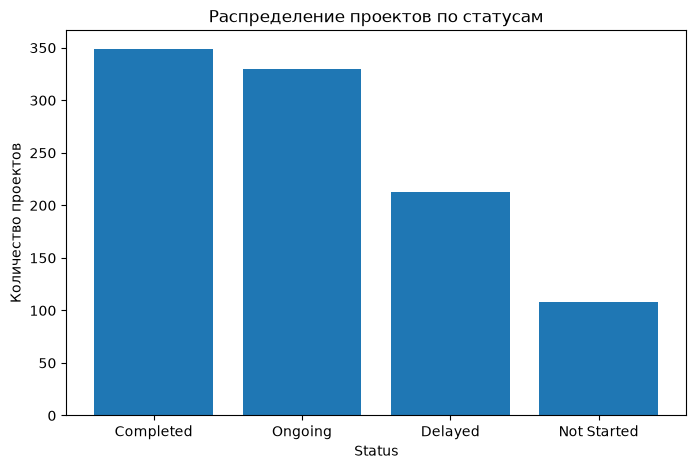

In [13]:
import matplotlib.pyplot as plt

status_counts = df["Status"].value_counts()

plt.figure(figsize=(8, 5))
plt.bar(status_counts.index, status_counts.values)

plt.xlabel("Status")
plt.ylabel("Количество проектов")
plt.title("Распределение проектов по статусам")

plt.show()

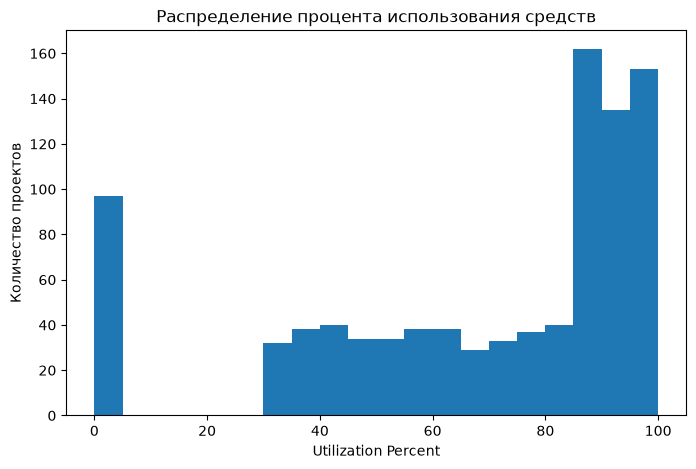

In [14]:
plt.figure(figsize=(8, 5))

plt.hist(df["Utilization_Percent"].dropna(), bins=20)

plt.xlabel("Utilization Percent")
plt.ylabel("Количество проектов")
plt.title("Распределение процента использования средств")

plt.show()

## Наблюдения по данным

1. В датасете представлены четыре статуса проектов: Completed, Ongoing, Delayed и Not Started. Наиболее многочисленными являются проекты со статусами Completed и Ongoing, а наименее многочисленными — Not Started.

2. Признак Utilization_Percent показывает процент использования выделенных средств. Его значения находятся в диапазоне от 0 до 99.97%.

3. В некоторых числовых признаках присутствуют пропущенные значения, поэтому перед обучением модели необходимо выполнить их обработку.

In [16]:
features = [
    "Sanctioned_Amount_Lakhs",
    "Fund_Released_Lakhs",
    "Fund_Utilized_Lakhs",
    "Utilization_Percent",
    "Physical_Target_Units",
    "Physical_Achievement_Units",
    "Beneficiaries_Target",
    "Beneficiaries_Covered"
]

X = df[features]
y = df["Status"]

print("Размер X:", X.shape)
print("Размер y:", y.shape)

Размер X: (1000, 8)
Размер y: (1000,)


In [17]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy="median")

X_imputed = pd.DataFrame(
    imputer.fit_transform(X),
    columns=X.columns,
    index=X.index
)

print("Количество пропусков после обработки:")
print(X_imputed.isnull().sum().sum())

Количество пропусков после обработки:
0


In [18]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_imputed,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Обучающая выборка:", X_train.shape)
print("Тестовая выборка:", X_test.shape)

Обучающая выборка: (800, 8)
Тестовая выборка: (200, 8)


In [19]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Масштабирование выполнено")

Масштабирование выполнено


In [20]:
from sklearn.linear_model import LogisticRegression

model_base = LogisticRegression(max_iter=1000)

model_base.fit(X_train_scaled, y_train)

print("Базовая модель обучена")

Базовая модель обучена


In [21]:
y_pred_base = model_base.predict(X_test_scaled)

print("Первые 20 предсказаний:")
print(y_pred_base[:20])

Первые 20 предсказаний:
['Completed' 'Completed' 'Ongoing' 'Ongoing' 'Completed' 'Completed'
 'Ongoing' 'Completed' 'Ongoing' 'Ongoing' 'Completed' 'Completed'
 'Ongoing' 'Completed' 'Ongoing' 'Completed' 'Ongoing' 'Ongoing' 'Ongoing'
 'Ongoing']


In [22]:
from sklearn.metrics import accuracy_score

accuracy_base = accuracy_score(y_test, y_pred_base)

print("Accuracy базовой модели:", accuracy_base)
print("Accuracy в процентах:", round(accuracy_base * 100, 2), "%")

Accuracy базовой модели: 0.7
Accuracy в процентах: 70.0 %


In [23]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_base))

              precision    recall  f1-score   support

   Completed       0.88      0.99      0.93        70
     Delayed       0.12      0.02      0.04        43
 Not Started       1.00      0.86      0.92        21
     Ongoing       0.54      0.79      0.64        66

    accuracy                           0.70       200
   macro avg       0.64      0.66      0.63       200
weighted avg       0.62      0.70      0.64       200



In [24]:
import seaborn as sns
import matplotlib.pyplot as plt

corr = X_imputed.corr()

plt.figure(figsize=(10, 8))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Корреляционная матрица числовых признаков")
plt.show()

ModuleNotFoundError: No module named 'seaborn'

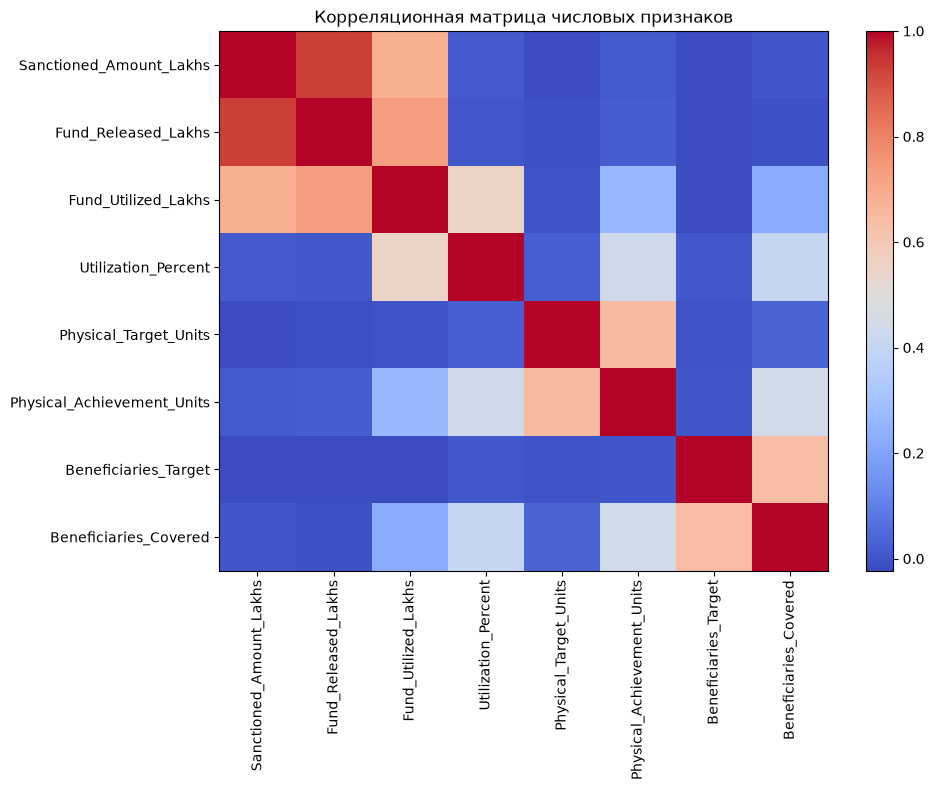

In [25]:
import matplotlib.pyplot as plt

corr = X_imputed.corr()

plt.figure(figsize=(10, 8))

plt.imshow(corr, cmap="coolwarm", aspect="auto")

plt.colorbar()

plt.xticks(
    range(len(corr.columns)),
    corr.columns,
    rotation=90
)

plt.yticks(
    range(len(corr.columns)),
    corr.columns
)

plt.title("Корреляционная матрица числовых признаков")

plt.tight_layout()
plt.show()

In [26]:
corr_pairs = corr.abs().unstack()

corr_pairs = corr_pairs[
    (corr_pairs < 1) &
    (corr_pairs >= 0.8)
]

print("Сильные корреляции (|r| >= 0.8):")
print(corr_pairs.sort_values(ascending=False))

Сильные корреляции (|r| >= 0.8):
Sanctioned_Amount_Lakhs  Fund_Released_Lakhs        0.931087
Fund_Released_Lakhs      Sanctioned_Amount_Lakhs    0.931087
dtype: float64


In [27]:
features_reduced = [
    "Fund_Released_Lakhs",
    "Fund_Utilized_Lakhs",
    "Utilization_Percent",
    "Physical_Target_Units",
    "Physical_Achievement_Units",
    "Beneficiaries_Target",
    "Beneficiaries_Covered"
]

X_reduced = X_imputed[features_reduced]

print("Признаки сокращённой модели:")
print(X_reduced.columns.tolist())

print("\nКоличество признаков:", X_reduced.shape[1])

Признаки сокращённой модели:
['Fund_Released_Lakhs', 'Fund_Utilized_Lakhs', 'Utilization_Percent', 'Physical_Target_Units', 'Physical_Achievement_Units', 'Beneficiaries_Target', 'Beneficiaries_Covered']

Количество признаков: 7


In [28]:
X_reduced_train = X_reduced.loc[X_train.index]
X_reduced_test = X_reduced.loc[X_test.index]

print("Размер train:", X_reduced_train.shape)
print("Размер test:", X_reduced_test.shape)

Размер train: (800, 7)
Размер test: (200, 7)


In [29]:
scaler_reduced = StandardScaler()

X_reduced_train_scaled = scaler_reduced.fit_transform(X_reduced_train)
X_reduced_test_scaled = scaler_reduced.transform(X_reduced_test)

print("Масштабирование сокращённой модели выполнено.")

Масштабирование сокращённой модели выполнено.


In [30]:
model_reduced = LogisticRegression(max_iter=1000)

model_reduced.fit(X_reduced_train_scaled, y_train)

print("Сокращённая модель обучена.")

Сокращённая модель обучена.


In [31]:
y_pred_reduced = model_reduced.predict(X_reduced_test_scaled)

print("Первые 20 предсказаний сокращённой модели:")
print(y_pred_reduced[:20])

Первые 20 предсказаний сокращённой модели:
['Completed' 'Completed' 'Ongoing' 'Ongoing' 'Completed' 'Completed'
 'Delayed' 'Completed' 'Ongoing' 'Ongoing' 'Completed' 'Completed'
 'Ongoing' 'Completed' 'Ongoing' 'Completed' 'Ongoing' 'Ongoing' 'Ongoing'
 'Ongoing']


In [32]:
accuracy_reduced = accuracy_score(y_test, y_pred_reduced)

print("Accuracy сокращённой модели:", accuracy_reduced)
print("Accuracy в процентах:", round(accuracy_reduced * 100, 2), "%")

Accuracy сокращённой модели: 0.72
Accuracy в процентах: 72.0 %


In [33]:
from sklearn.metrics import f1_score

f1_macro_base = f1_score(y_test, y_pred_base, average="macro")
f1_macro_reduced = f1_score(y_test, y_pred_reduced, average="macro")

print("F1 базовой модели:", round(f1_macro_base, 3))
print("F1 сокращённой модели:", round(f1_macro_reduced, 3))

F1 базовой модели: 0.634
F1 сокращённой модели: 0.634


In [34]:
comparison = pd.DataFrame({
    "Модель": [
        "Базовая модель",
        "Сокращённая модель"
    ],
    "Количество признаков": [
        8,
        7
    ],
    "Accuracy": [
        accuracy_base,
        accuracy_reduced
    ],
    "F1-score (macro)": [
        f1_macro_base,
        f1_macro_reduced
    ]
})

print(comparison)

               Модель  Количество признаков  Accuracy  F1-score (macro)
0      Базовая модель                     8      0.70          0.634175
1  Сокращённая модель                     7      0.72          0.633520


In [35]:
from sklearn.preprocessing import label_binarize
import numpy as np
import matplotlib.pyplot as plt

# Фактические классы переводим в 0 и 1
y_test_bin = label_binarize(
    y_test,
    classes=model_reduced.classes_
)

# Вероятности принадлежности к каждому классу
y_proba = model_reduced.predict_proba(X_reduced_test_scaled)

print("Размер фактических значений:", y_test_bin.shape)
print("Размер предсказанных вероятностей:", y_proba.shape)

Размер фактических значений: (200, 4)
Размер предсказанных вероятностей: (200, 4)


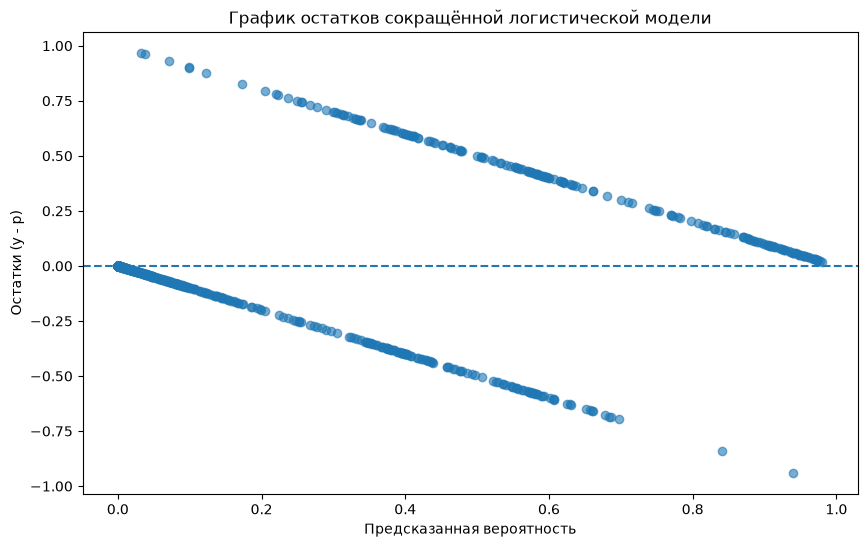

In [36]:
# Рассчитываем остатки
residuals = y_test_bin - y_proba

# Строим график
plt.figure(figsize=(10, 6))

plt.scatter(
    y_proba.ravel(),
    residuals.ravel(),
    alpha=0.6
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.xlabel("Предсказанная вероятность")
plt.ylabel("Остатки (y - p)")
plt.title("График остатков сокращённой логистической модели")

plt.show()

## Итоговый вывод

В работе была построена базовая многоклассовая модель логистической регрессии на основе 8 числовых признаков.

При анализе корреляционной матрицы была обнаружена сильная корреляция между признаками Sanctioned_Amount_Lakhs и Fund_Released_Lakhs (r = 0.93). Для уменьшения избыточности признаков Sanctioned_Amount_Lakhs был удалён из сокращённой модели.

После этого была обучена сокращённая модель на 7 признаках.

Результаты сравнения:

- базовая модель: Accuracy = 70%, F1-score = 0.634;
- сокращённая модель: Accuracy = 72%, F1-score = 0.634.

Таким образом, сокращённая модель использует на один признак меньше, при этом её Accuracy немного выше, а F1-score практически не изменился. Это показывает, что удаление сильно коррелирующего признака не привело к заметному ухудшению качества модели.

На графике остатков наблюдаются отдельные полосы, что связано с многоклассовой классификацией и использованием вероятностей. Поэтому классические допущения линейной регрессии нельзя напрямую применять к данной модели.

В качестве итогового варианта можно использовать логистическую регрессию на сокращённом наборе из 7 признаков, так как она сохраняет качество модели при меньшем количестве признаков.